In [1]:
# %matplotlib inline
%config InlineBackend.figure_format = "retina"
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

import matplotlib as mpl

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans"],
})

import seaborn as sns
sns.set_theme(context="talk", style="whitegrid", 
              palette="colorblind", color_codes=True, 
              rc={"figure.figsize": [12, 8]})

import yfinance as yf
import numpy as np
import pandas as pd
import quantstats as qs

import requests
import csv

#### empresas

In [2]:
# Carteira teorica do Idiv

url = "https://raw.githubusercontent.com/BDonadelli/Finance-playground/main/data/Cart_Idiv.csv"

response = requests.get(url)
response.encoding = 'utf-8'  # ou 'latin-1' se necessário

# Divide o conteúdo em linhas
linhas = response.text.splitlines()

# Ignora as duas primeiras e duas últimas linhas
linhas_filtradas = linhas[2:-2]

# Extrai a primeira coluna de cada linha restante
ASSETS = []
for linha in linhas_filtradas:
    # O separador é ";", pega o primeiro campo
    campos = linha.split(';')
    if campos:  # garante que a linha não está vazia
        ASSETS.append((campos[0],campos[4]))

In [3]:
ASSETS = [(ticker, float(str(value).replace(',', '.'))) for ticker, value in ASSETS]
# ASSETS = [  'ODPV3' , 'TASA4' , 'KEPL3' , # quality factor
#             'EMBJ3' , 'POMO4' , 'JSLG3' , # momnetum 
#             'GOAU4' , 'PETR4' , 'LIGT3' , # value
#             'EVEN3' , 'SLCE3' , 'MDIA3' ]  # growth

In [ ]:
pesos_indice = [value for ticker, value in ASSETS]
tickers = [ticker+'.SA' for ticker, value in ASSETS]
tickers.sort()

In [5]:
ASSETS = [  'ODPV3' , 'TASA4' , 'KEPL3' , # quality factor
            # 'EMBJ3' , 'POMO4' , 'JSLG3' , # momnetum 
            # 'GOAU4' , 'PETR4' , 'LIGT3' , # value
            # 'EVEN3' , 'SLCE3' , 'MDIA3'   # growth
]
tickers = [x+'.SA' for x in ASSETS]
tickers.sort()

#### parametros

In [6]:
rf = 0.14                   # taxa livre de risco
n_days=252               # dias no ano do calendario financeiro, assumindo dados diários pegos no Yahoo Finance
n_monte_carlo = 10    # quantidade de carteiras na simulação

# Definição do período e download dos dados
data_inicio = '2010-01-01'
data_fim = '2025-12-31'

#### preços de fechamento

Baixa dados e limpa a base

In [8]:
prices = yf.download(tickers, start=data_inicio, end=data_fim , auto_adjust=True)['Close']
prices.columns = [col.replace('.SA', '') for col in prices.columns]

benchm = yf.download('^BVSP', start=data_inicio, end=data_fim , auto_adjust=True)['Close']

[*********************100%***********************]  3 of 3 completed
[*********************100%***********************]  1 of 1 completed


In [9]:
benchm.isna().sum()

Ticker
^BVSP    0
dtype: int64

In [11]:
prices[prices.isnull().any(axis=1)].values


array([], shape=(0, 3), dtype=float64)

In [12]:
prices.isna().sum()

KEPL3    0
ODPV3    0
TASA4    0
dtype: int64

In [13]:
# Empresas com mais de 'limiar' dados faltantes
limiar = 10
missing = prices.isna().sum()
empresas_missing = missing[missing > 10].index.tolist()

# print(empresas_missing)
print(missing[missing > 10].sort_values(ascending=False))

Series([], dtype: int64)


In [14]:
# mantem colunas (axis=1) ue possuem no mínimo len(prices) - 20 valores não-nulos.
prices = prices.dropna(axis=1, thresh=len(prices) - 10)
# preenche dados faltantes repetindo ultimo valor
prices = prices.ffill()

In [ ]:
import plotly.express as px

fig = px.line(
    prices[empresas_missing].reset_index(),
    x='Date',
    y=empresas_missing,
    title='Empresas com mais de 10 dados faltantes',
    labels={'value': 'Preço', 'Date': 'Data', 'variable': 'Empresa'}
)

fig.show()

In [16]:
returns = prices.pct_change().dropna()

In [18]:
print(len(prices),len(returns),len(tickers),len(ASSETS),len(prices.columns))

3974 3973 3 3 3


#### correlações

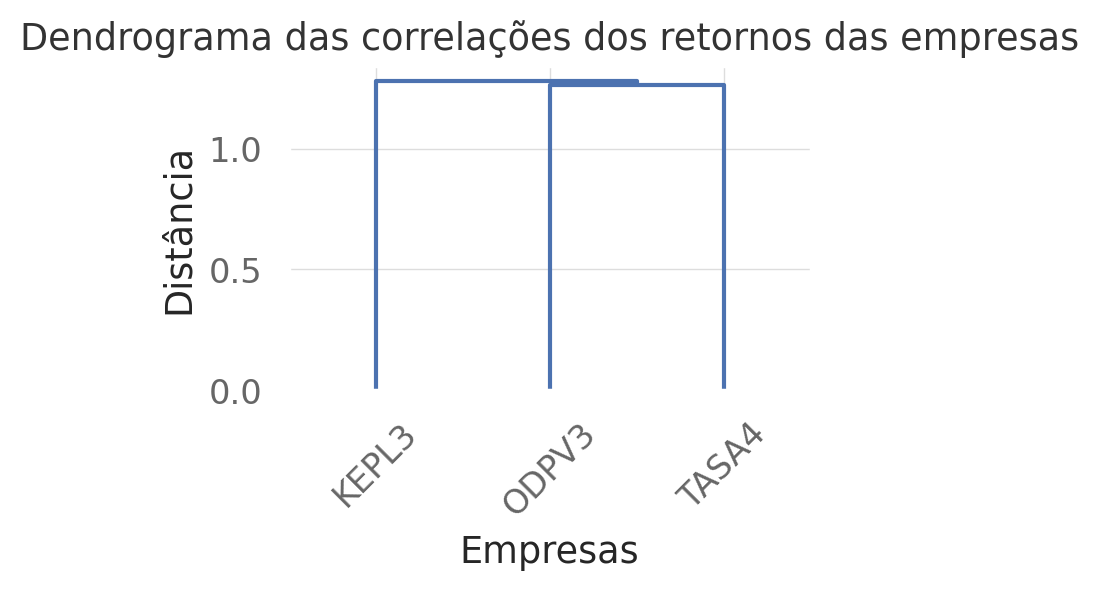

In [19]:
from scipy.cluster.hierarchy import dendrogram, linkage, distance


correl = returns.corr()
# Calcular a distância entre as variáveis
dist = distance.pdist(correl.values)
# Calcular o linkage
link_mat = linkage(correl.values, method='average')

# Criar um dendrograma
plt.figure(figsize=(len(ASSETS), 2))
dendrograma = dendrogram(link_mat,labels=correl.columns)
plt.title('Dendrograma das correlações dos retornos das empresas')
plt.ylabel('Distância')
plt.xlabel('Empresas')
plt.xticks(rotation=45)
plt.show()


<Figure size 500x500 with 0 Axes>

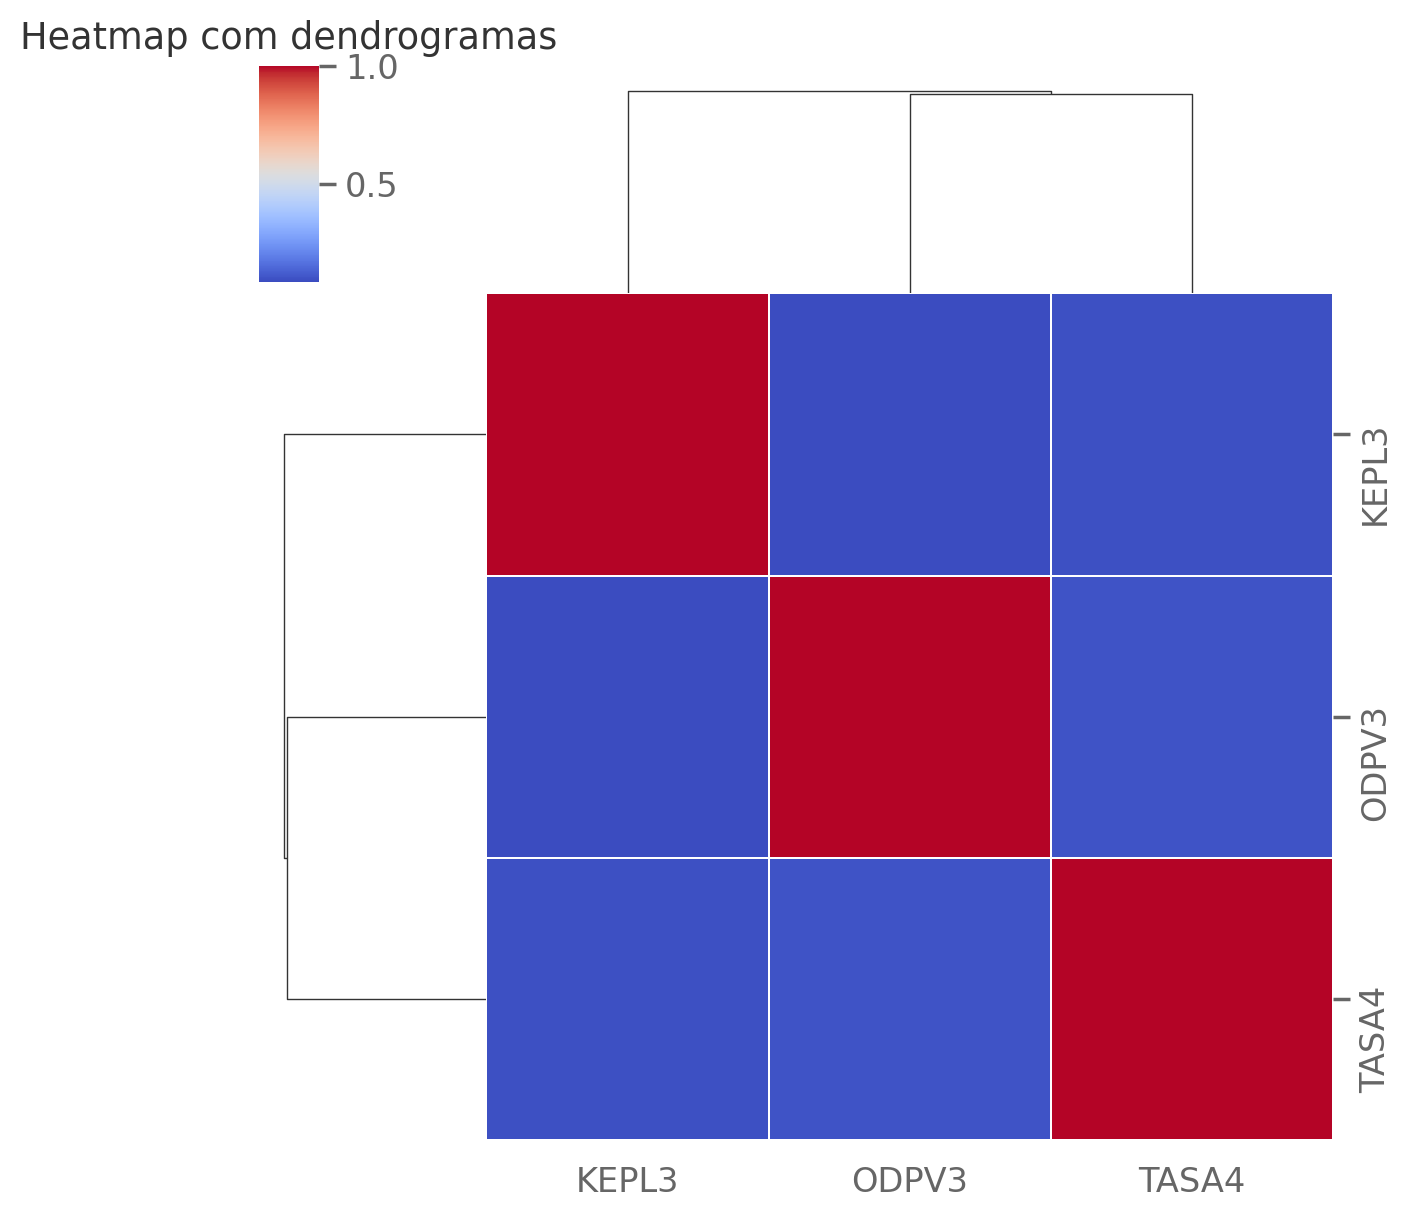

In [20]:
# Plotar o heatmap com dendrogramas
plt.figure(figsize=(5,5))
sns.clustermap(correl, method='average', metric='euclidean', cmap='coolwarm', linewidths=0.1,
               figsize=(6,6), row_cluster=True, col_cluster=True)
plt.title('Heatmap com dendrogramas')
plt.show()

### simulação Monte Carlo

In [21]:
def print_summary(perf, weights, assets, name):
    """
    Função auxiliar para imprimir o resumo do desempenho de um portfólio.
    
    Args:
        perf (pd.Series): Série contendo as métricas de desempenho
        weights (np.array): array contendo os pesos do portfólio
        assets (list): lista dos nomes dos ativos
        name (str): o nome do portfólio

    Returns:
        df: dataframe Python 'asset : weight'
    """
    print(f" --- Carteira {name} ----")
    print("\nPerformance")
    for index, value in perf.items():
        print(f"{index}: {100 * value:.2f}% ", end="", flush=True)
    print("\nPesos dos ativos")
    for x, y in zip(assets, weights):
        print(f"{x}: {100*y:.2f}% ", end="", flush=True)
        
    return pd.DataFrame.from_dict({x: y for x, y in zip(assets, weights)}, orient='index', columns=['Valores'])

# ---

from pypfopt import risk_models, expected_returns
def port_metrics(data):
    """
    Args:
        data : dataframe com preços dos ativos  de  uma carteira

    Returns:
        Retorno e covariancia anualizados de uma carteira
    """
    
    mu = expected_returns.mean_historical_return(data)
    S =  risk_models.CovarianceShrinkage(data).ledoit_wolf()

    return mu, S

# ---

def random_protfolios (prices , n_port = n_monte_carlo , rf=rf) :
    """
    Gera um data frame com as métricas de performance de carteiras, 
    sobre uma lista de assets, com pesos sorteados 

    Args:
        prices :  dataframe com preços dos ativos  de  uma carteira
        n_port : quantidade de carteiras geradas
        rf : taxa livre de risco

    Returns:
        matriz dos pesos
        Dataframe com métricas de performance das carteiras
  """

    avg_ret , cov = port_metrics(prices)
    n_assets = len(prices.columns)

    #  pesos dos ativos, cada peso weights[i] uma carteira
    # np.random.seed(42)
    # weights = np.random.random(size=(n_port, n_assets))     # sorteia pesos
    # weights /=  np.sum(weights, axis=1)[:, np.newaxis]      # normaliza os pesos
    weights = np.random.dirichlet(np.ones(n_assets), size=n_port)

    # metricas das carteiras geradas
    #  retorno das carteiras
    portf_rtns = np.dot(weights,  avg_ret )
    #  vol das carterias 
    portf_vol = []
    for i in range(0, len(weights)):
        vol = np.sqrt(np.dot(weights[i].T, np.dot(cov, weights[i])))
        portf_vol.append(vol)
    portf_vol = np.array(portf_vol)  
    #  sharpe das carterias 
    portf_sharpe_ratio = (portf_rtns - rf)/ portf_vol

    # metricas anualizadas
    MC_portf_results_df = pd.DataFrame(
        {"retorno": portf_rtns ,
         "volatilidade": portf_vol,
         "sharpe_ratio": portf_sharpe_ratio }
    )

    return weights, pd.DataFrame({"retorno": portf_rtns, "volatilidade": portf_vol,"sharpe_ratio": portf_sharpe_ratio})



In [23]:
random_protfolios (prices , n_port = 1 , rf=0)[1]

,retorno,volatilidade,sharpe_ratio
0,-0.052381,0.463542,-0.113002


In [24]:
pesos, MC_portf_results = random_protfolios(prices)
MC_portf_results

,retorno,volatilidade,sharpe_ratio
0,0.087937,0.268288,-0.194058
1,0.077395,0.265031,-0.236218
2,0.023326,0.348253,-0.335026
3,0.091009,0.296233,-0.165380
4,0.108624,0.392628,-0.079912
5,-0.053033,0.478883,-0.403091
6,0.061759,0.271281,-0.288412
7,-0.050645,0.457150,-0.417031
8,-0.014310,0.419652,-0.367709
9,-0.015147,0.375984,-0.412642


#### carteira com maior sharpe

In [25]:
MC_max_sharpe_index = np.argmax(MC_portf_results["sharpe_ratio"])    # indice da carteira max sharpe
MC_max_sharpe_portf = MC_portf_results.loc[MC_max_sharpe_index]      # metricas da certeira de max sharpe
MC_max_sharpe_portf


retorno         0.108624
volatilidade    0.392628
sharpe_ratio   -0.079912
Name: 4, dtype: float64

In [26]:
pesos[MC_max_sharpe_index]

array([0.84472813, 0.06698208, 0.0882898 ])

 --- Carteira maior sharpe ----

Performance
retorno: 10.86% volatilidade: 39.26% sharpe_ratio: -7.99% 
Pesos dos ativos
KEPL3.SA: 84.47% ODPV3.SA: 6.70% TASA4.SA: 8.83% 

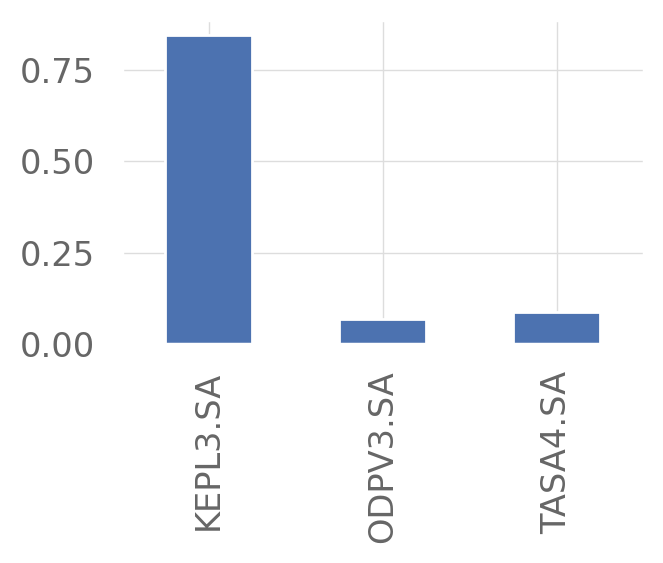

In [28]:
MC_Max_Sharpe = print_summary(MC_max_sharpe_portf, pesos[MC_max_sharpe_index] , tickers, 'maior sharpe')
MC_Max_Sharpe.plot.bar(figsize=(len(prices.columns),2), legend=False);

#### carteira maior retorno

 --- Carteira maior retorno ----

Performance
retorno: 10.86% volatilidade: 39.26% sharpe_ratio: -7.99% 
Pesos dos ativos
KEPL3.SA: 84.47% ODPV3.SA: 6.70% TASA4.SA: 8.83% 

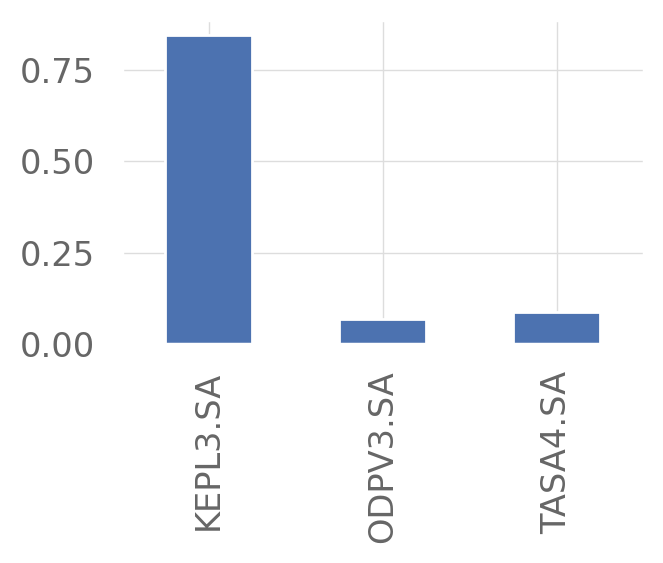

In [29]:
MC_max_ret_index = np.argmax(MC_portf_results["retorno"])    
MC_max_ret_portf = MC_portf_results.loc[MC_max_ret_index] 

MC_Max_Ret = print_summary(MC_max_ret_portf, pesos[MC_max_ret_index] , tickers, 'maior retorno')
MC_Max_Ret.plot.bar(figsize=(len(prices.columns),2), legend=False);


#### carteira com menor vol

 --- Carteira menor vol ----

Performance
retorno: 7.74% volatilidade: 26.50% sharpe_ratio: -23.62% 
Pesos dos ativos
KEPL3.SA: 18.89% ODPV3.SA: 68.22% TASA4.SA: 12.89% 

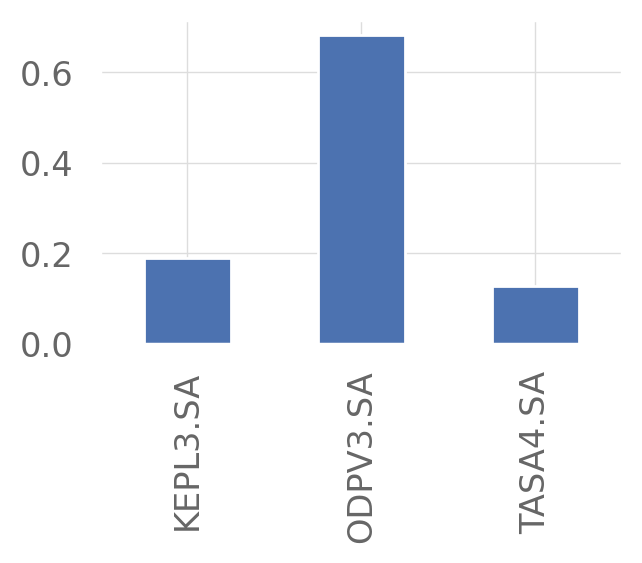

In [30]:
MC_min_vol_index = np.argmin(MC_portf_results["volatilidade"]) # indice da carteira min vol
MC_min_vol_portf = MC_portf_results.loc[MC_min_vol_index]       # metricas da certeira de min vol

MC_Min_Vol = print_summary(MC_min_vol_portf, pesos[MC_min_vol_index] , tickers, 'menor vol')
MC_Min_Vol.plot.bar(figsize=(len(prices.columns),2), legend=False);

grafico

In [31]:
if n_monte_carlo <= 10**5 :
    import plotly.graph_objects as go

    fig = go.Figure()

    fig.add_trace(go.Scatter(x=MC_portf_results["volatilidade"],y=MC_portf_results["retorno"],
                            mode="markers",marker=dict(color=MC_portf_results["sharpe_ratio"],
                                                        colorscale="Viridis",
                                                        colorbar=dict(title="Sharpe Ratio"),
                                                        ), showlegend=False))
    # ponto de Sharpe Ratio máximo
    fig.add_trace(go.Scatter(x=[MC_max_sharpe_portf.volatilidade],y=[MC_max_sharpe_portf.retorno],
                            mode="markers",marker=dict(color="black", symbol="star", size=12,),
                            name="Max Sharpe Ratio",))

    # ponto de volatilidade mínima
    fig.add_trace(go.Scatter(x=[MC_min_vol_portf.volatilidade],y=[MC_min_vol_portf.retorno],
                            mode="markers",marker=dict(color="black", symbol="diamond", size=12,),
                            name="Min Vol",))

    fig.update_layout(xaxis_title="Risco",yaxis_title="Retorno",
        title="Retorno vs. Risco com Sharpe Ratio como Mapa de Calor",
        legend=dict(
            x=1,  # Posição horizontal (0 = esquerda, 1 = direita)
            y=1,  # Posição vertical (0 = inferior, 1 = superior)
            xanchor="right",  # Ancora horizontal da legenda
            yanchor="top"   # Ancora vertical da legenda
        ))
    # Exiba o gráfico
    fig.show()

else : pass
    # avg_ret_aa , cov_mat_aa = port_metrics(prices)
    # MARKERS = ["o"]*len(prices.columns)

    # with sns.plotting_context("paper"):
    #     fig, ax = plt.subplots()
    #     MC_portf_results.plot(kind="scatter", x="volatilidade", 
    #                         y="retorno", c="sharpe_ratio",
    #                         cmap="RdYlGn", edgecolors="black", 
    #                         ax=ax)
    #     ax.set(xlabel="Volatilidade", 
    #         ylabel="Retorno", 
    #         title="Fronteira eficiente via simulação")
    #     # ax.plot(ef_vol_list, ef_rtn_list, "b--")
    #     for asset_index in range(len(prices.columns)):
    #         ax.scatter(x=np.sqrt(cov_mat_aa.iloc[asset_index, asset_index]), 
    #                 y=avg_ret_aa[asset_index], 
    #                 marker=MARKERS[asset_index], 
    #                 s=150, color="black",
    #                 # label=ASSETS[asset_index]
    #                 )
    #         ax.text(x=np.sqrt(cov_mat_aa.iloc[asset_index, asset_index])+.005,
    #             y=avg_ret_aa[asset_index]+.01,
    #             s=ASSETS[asset_index],
    #             fontsize=10, ha='center', va='bottom') 
            

    #     # Ponto de Sharpe Ratio máximo
    #     ax.scatter(MC_max_sharpe_portf.volatilidade, MC_max_sharpe_portf.retorno,
    #             marker="*", s=100, color="black", label="Max Sharpe Ratio")

    #     # Ponto de volatilidade mínima
    #     ax.scatter(MC_min_vol_portf.volatilidade, MC_min_vol_portf.retorno,
    #             marker="D", s=100, color="black", label="Min Vol")

    #     ax.legend()

    #     sns.despine()
    #     plt.tight_layout()
    #     # plt.savefig("images/figure_11_10", dpi=200)

### performance

In [32]:
portfolio_returns = pd.Series(
    np.dot(pesos[MC_max_sharpe_index], returns.T ), 
    index=returns.index
)


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


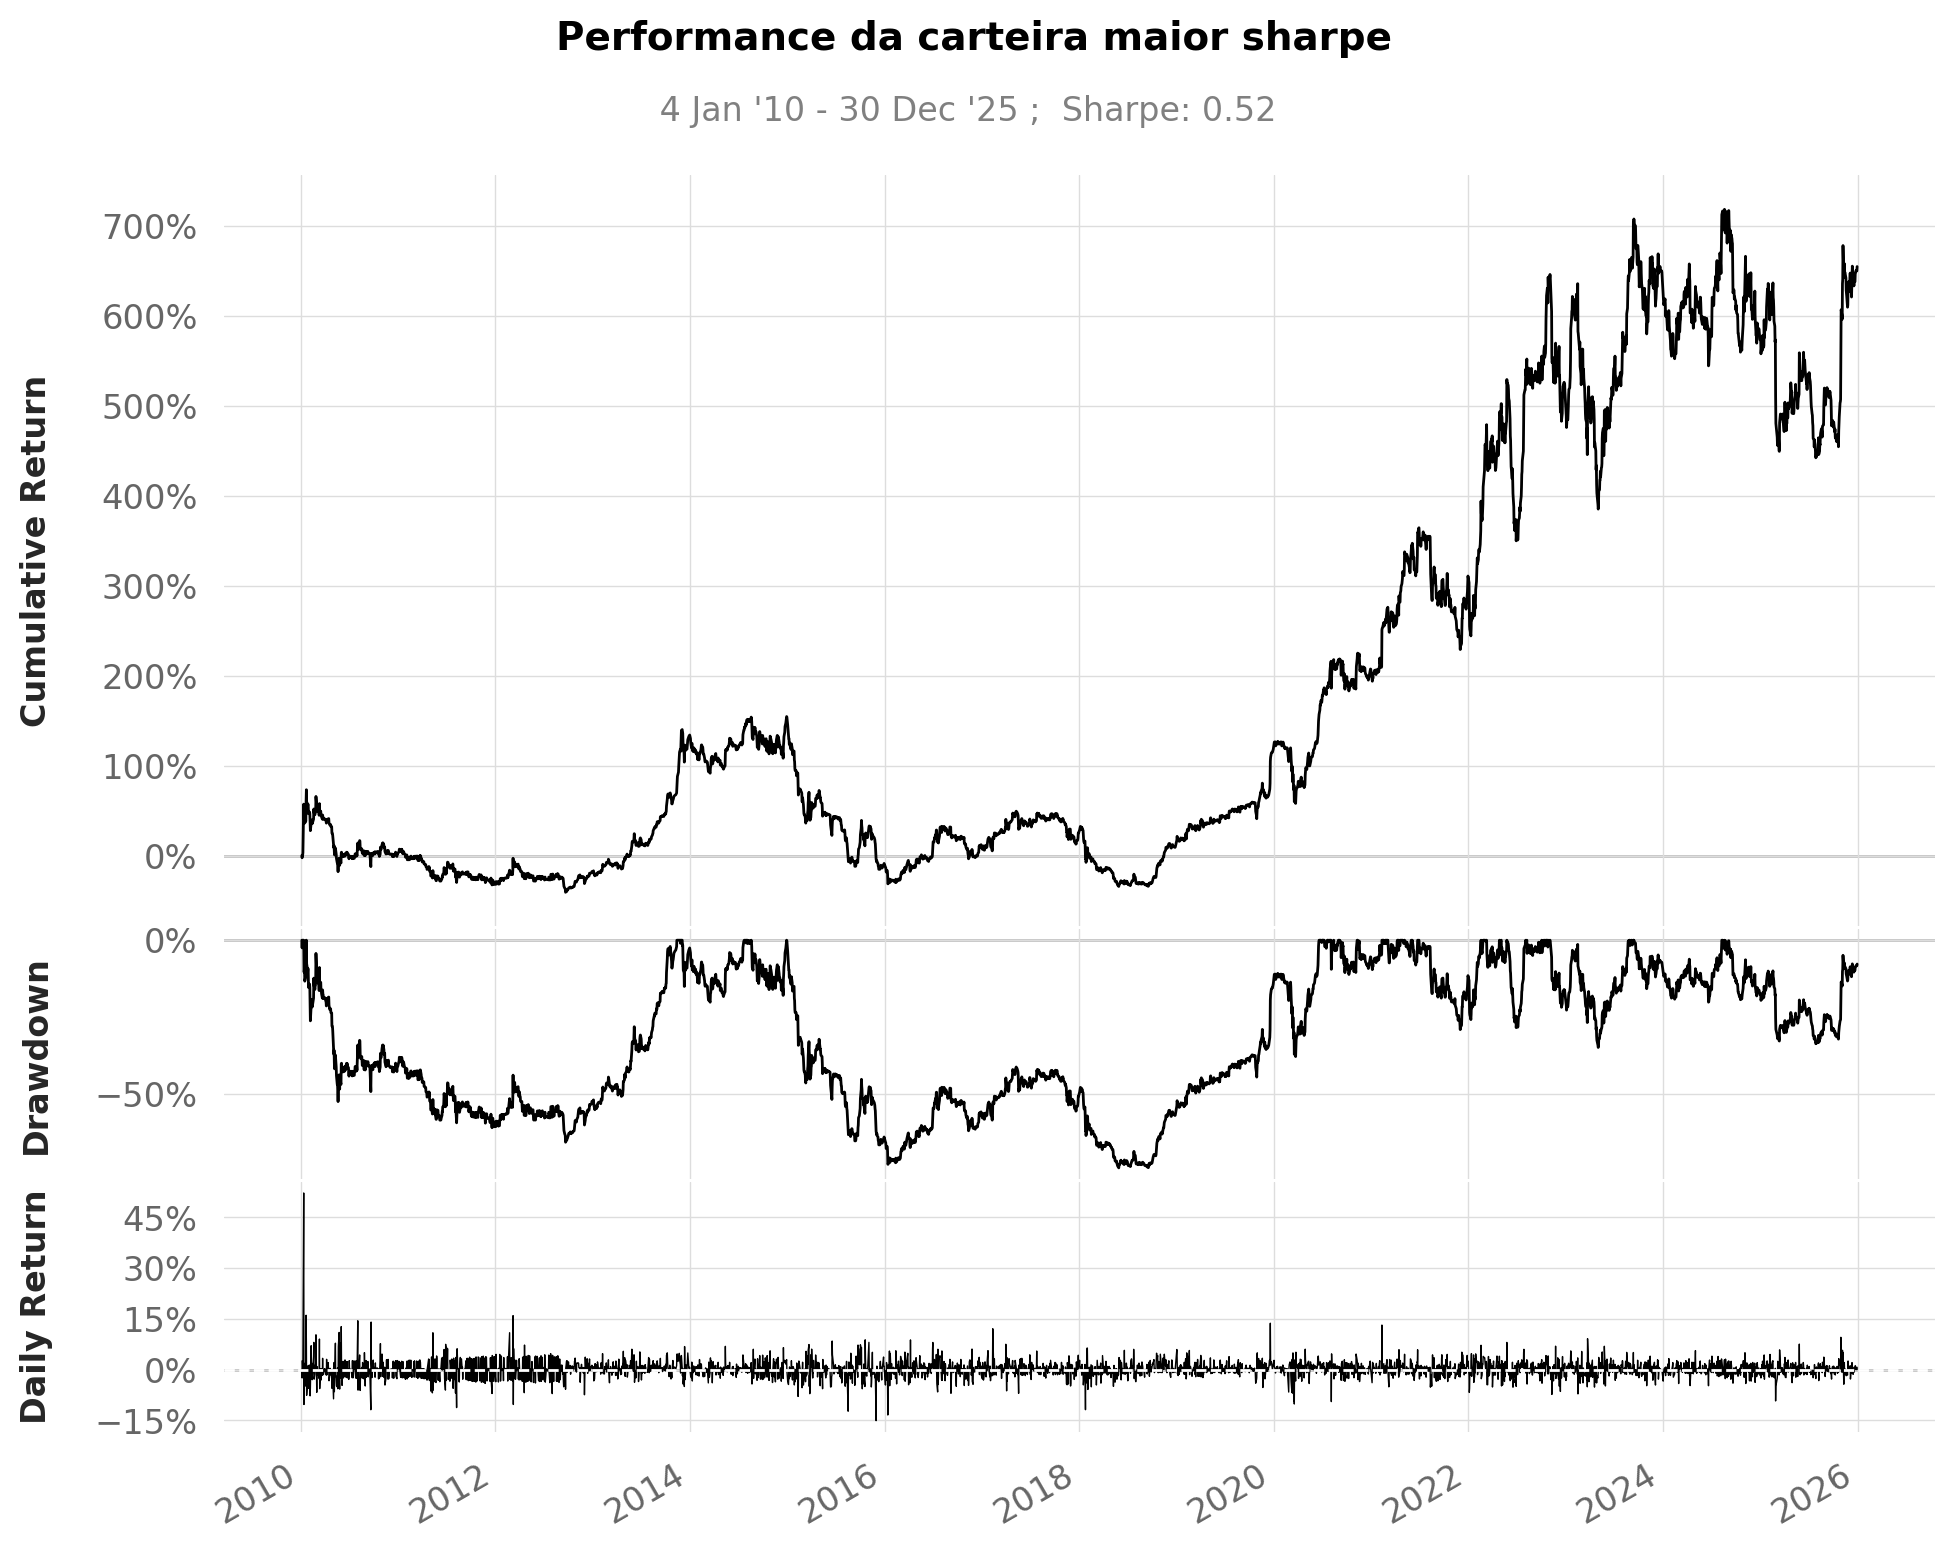

In [33]:
portfolio_returns.index = pd.to_datetime(portfolio_returns.index)
qs.plots.snapshot(portfolio_returns, title="Performance da carteira maior sharpe", grayscale=True)

In [34]:
qs.reports.html(portfolio_returns, benchmark="^BVSP")


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

In [35]:
qs.reports.metrics(portfolio_returns, benchmark="^BVSP", mode="basic" , rf=rf)


Parameter       Value
--------------  -----------------
Benchmark       Benchmark (^BVSP)
Risk-Free Rate  14.0%
Periods/Year    252
Compounded      Yes
Match Dates     Yes


                     Benchmark (^BVSP)    Strategy
-------------------  -------------------  ----------
Start Period         2010-01-06           2010-01-06
End Period           2025-12-30           2025-12-30
Risk-Free Rate       14.0%                14.0%
Time in Market       100.0%               100.0%

Cumulative Return    129.39%              674.28%
CAGR﹪               5.41%                13.87%

Sharpe               -0.22                0.19
Prob. Sharpe Ratio   0.0%                 0.0%
Sortino              -0.31                0.29
Sortino/√2           -0.22                0.2
Omega                0.96                 1.04

Max Drawdown         -48.63%              -74.23%
Max DD Date          2016-01-26           2018-05-29
Max DD Period Start  2010-11-05           2014-12-30
Max DD Period End    2017-0

In [ ]:
[method for method in dir(qs.stats) if method[0] != "_"]

### backtest


In [36]:

# Inicialização de DataFrames para armazenar os pesos otimizados
pesos_max_sr = pd.DataFrame(index=prices.index, columns=prices.columns)
pesos_min_vol = pd.DataFrame(index=prices.index, columns=prices.columns)


In [ ]:
def optim_weights(precos, objetivo='sharpe'):
    
    carteiras , portf_results = random_protfolios(precos)
    
    try:
        if objetivo == 'sharpe':
            index = np.argmax(portf_results["sharpe_ratio"])    # indice da carteira max sharpe
            # metrics = portf_results.loc[index]      # metricas da certeira de max sharpe
            weights = carteiras[index]
        else:
             index = np.argmin(portf_results["volatilidade"]) # indice da carteira min vol
            #  metrics = portf_results.loc[index]       # metricas da certeira de min vol
             weights = carteiras[index]
            
        return weights
    except Exception as e:
        
        n = len(precos.columns)
        return {ticker: 1.0/n for ticker in precos.columns}


In [38]:
anos = prices.index.year.unique()

for ano in sorted(anos+3):
    if ano < int(data_fim[:4]) : 
        # Dados de "Treino" (Ano Atual)
        # dados_treino = prices[prices.index.year == ano]
        dados_treino = prices.loc[:f"{ano}-12-31"].tail(252*3)  # 3 anos
        
        # Otimização
        w_sharpe = optim_weights(dados_treino, objetivo='sharpe')
        w_vol = optim_weights(dados_treino, objetivo='vol')
        
        # Aplica os pesos no ano seguinte (Teste)
        mascara_proximo_ano = (prices.index.year == ano + 1)
        
        for ticker in prices.columns:
            pesos_max_sr.loc[mascara_proximo_ano, ticker] = w_sharpe.get(ticker, 0)
            pesos_min_vol.loc[mascara_proximo_ano, ticker] = w_vol.get(ticker, 0)

# Limpeza final dos NaNs (onde não houve teste, como o primeiro ano)
pesos_max_sr = pesos_max_sr.dropna()
pesos_min_vol = pesos_min_vol.dropna()

In [39]:
import bt
# Estratégia de Benchmark (Ibovespa)
s0 = bt.Strategy('Ibovespa', [  # Simula uma carteira buy and hold — compra uma vez e nunca mais rebalanceia. Serve como referência de comparação.
    bt.algos.RunOnce(),         # Executa apenas uma vez (no início)
    bt.algos.SelectAll(),       # Seleciona todos os ativos
    bt.algos.WeighEqually(),    # Distribui pesos iguais
    bt.algos.Rebalance()        # Rebalanceia, é sempre necessário para efetivar qualquer alocação, mas quem controla a frequência é o Run*()
])

# Estratégia de Máximo Sharpe (Utilizando os pesos calculados anteriormente)
s1 = bt.Strategy('Max Sharpe', [        # Simula uma carteira Maximo Sharpe
bt.algos.RunMonthly(),                  # Rebalanceamento mensal
    bt.algos.SelectAll(),
    bt.algos.WeighTarget(pesos_max_sr), # Aplica os pesos otimizados
    bt.algos.Rebalance()
])

s2 = bt.Strategy('Min Vol', [            # Simula uma carteira Mínima Volatilidade
    bt.algos.RunMonthly(),               # Rebalanceamento mensal
    bt.algos.SelectAll(),
    bt.algos.WeighTarget(pesos_min_vol), # Aplica os pesos otimizados
    bt.algos.Rebalance()
])

s3 = bt.Strategy('Equal weight', [  # Simula uma carteira pesos iguais
    bt.algos.RunMonthly(),          # Rebalanceamento mensal
    bt.algos.SelectAll(),
    bt.algos.WeighEqually(), 
    bt.algos.Rebalance()
])

data_inicio = pd.to_datetime(data_inicio)

'''
bt.Backtest(estratégia, dados) vincula uma estratégia aos dados históricos. 
O filtro .loc[...index.year > data_inicio.year] corta os dados, usando apenas os anos posteriores ao ano de início.
o filtro usa > e não >=, o ano de data_inicio em si é excluído. Se data_inicio = 2018, os dados começam em 2019.
'''
bt0 = bt.Backtest(s0,benchm.loc[benchm.index.year > data_inicio.year])
bt1 = bt.Backtest(s1,prices.loc[prices.index.year > data_inicio.year])
bt2 = bt.Backtest(s2,prices.loc[prices.index.year > data_inicio.year])
bt3 = bt.Backtest(s3,prices.loc[prices.index.year > data_inicio.year])

resultado = bt.run(bt0,bt1,bt2,bt3) # executa todos os backtests e agrega os resultados em um único objeto
resultado.display()                  # imprime uma tabela com as métricas de desempenho de cada estratégia,

Stat                 Ibovespa    Max Sharpe    Min Vol     Equal weight
-------------------  ----------  ------------  ----------  --------------
Start                2011-01-02  2011-01-02    2011-01-02  2011-01-02
End                  2025-12-30  2025-12-30    2025-12-30  2025-12-30
Risk-free rate       0.00%       0.00%         0.00%       0.00%

Total Return         127.63%     130.05%       130.05%     258.98%
Daily Sharpe         0.36        0.34          0.34        0.44
Daily Sortino        0.50        0.52          0.52        0.67
CAGR                 5.64%       5.71%         5.71%       8.90%
Max Drawdown         -46.70%     -70.65%       -70.65%     -71.62%
Calmar Ratio         0.12        0.08          0.08        0.12

MTD                  1.28%       0.94%         0.94%       0.94%
3m                   10.08%      6.12%         6.12%       6.12%
6m                   15.87%      -2.55%        -2.55%      -2.55%
YTD                  33.55%      -2.90%        -2.90%      -

In [40]:
import plotly.express as px
px.line(resultado.prices)

<module 'matplotlib.pyplot' from '/home/yair/bin/pythorix/lib/python3.12/site-packages/matplotlib/pyplot.py'>

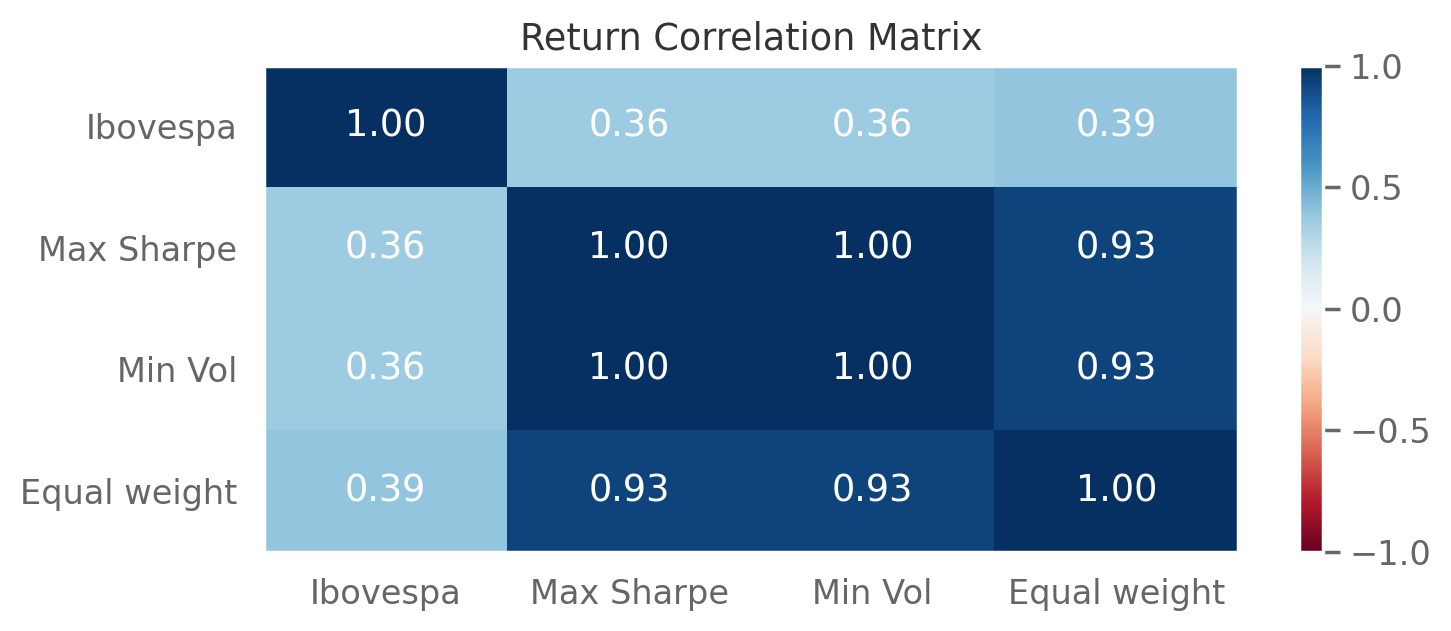

In [41]:
resultado.plot_correlation(figsize=(7,3))

In [42]:
for port in resultado.keys():
    print(port)
    resultado.display_monthly_returns(port)
    print(' ')


Ibovespa
  Year    Jan    Feb     Mar    Apr     May     Jun    Jul    Aug     Sep    Oct    Nov    Dec     YTD
------  -----  -----  ------  -----  ------  ------  -----  -----  ------  -----  -----  -----  ------
  2011  -4.74   1.19    1.75  -3.5    -2.24   -3.35  -5.61  -3.86   -7.2   11.18  -2.45  -0.21  -18.49
  2012  10.85   4.25   -1.93  -4.08  -11.58   -0.24   3.12   1.67    3.61  -3.48   0.7    5.9     7.21
  2013  -1.91  -3.82   -1.82  -0.76   -4.19  -11      1.59   3.57    4.53   3.56  -3.18  -1.81  -15.13
  2014  -7.3   -1.11    6.84   2.33   -0.73    3.66   4.87   9.53  -11.43   0.92   0.06  -8.3    -2.83
  2015  -6.02   9.66   -0.82   9.65   -6.01    0.59  -4.06  -8.1    -3.26   1.74  -1.58  -3.8   -12.93
  2016  -6.57   5.7    16.41   7.48   -9.82    6.12  10.91   1.01    0.78  10.96  -4.55  -2.65   37.66
  2017   7.2    3.01   -2.46   0.63   -4.03    0.29   4.69   7.29    4.78   0.02  -3.08   6.03   26.22
  2018  10.93   0.66   -0.13   0.86  -10.69   -5.1    8.7   -3.1